In [1]:
from mapc_cmab.agents.hierarchical_dqn  import HierarchicalMapcDQNAgent 
from mapc_cmab.agents.mapc_cmab_agent_factory import MapcDQNAgentFactory
from mapc_cmab.envs.scenario_impl import small_office_scenario 
import jax 
import jax.numpy as jnp 
from tqdm import tqdm 


In [2]:
d_ap = 10
d_sta = 2
scenario = small_office_scenario(d_ap=d_ap, d_sta=d_sta)

{'str_repr': 'static_small_office_10_2', 'CCA_THRESHOLD': -82.0, 'DEFAULT_CHANNEL_WIDTH': 20, 'associations': {0: [4, 5, 6, 7], 1: [8, 9, 10, 11], 2: [12, 13, 14, 15], 3: [16, 17, 18, 19]}, 'pos': Array([[ 0.       ,  0.       ],
       [10.       ,  0.       ],
       [10.       , 10.       ],
       [ 0.       , 10.       ],
       [-1.4142135, -1.4142135],
       [ 1.4142135, -1.4142135],
       [ 1.4142135,  1.4142135],
       [-1.4142135,  1.4142135],
       [ 8.585787 , -1.4142135],
       [11.414213 , -1.4142135],
       [11.414213 ,  1.4142135],
       [ 8.585787 ,  1.4142135],
       [ 8.585787 ,  8.585787 ],
       [11.414213 ,  8.585787 ],
       [11.414213 , 11.414213 ],
       [ 8.585787 , 11.414213 ],
       [-1.4142135,  8.585787 ],
       [ 1.4142135,  8.585787 ],
       [ 1.4142135, 11.414213 ],
       [-1.4142135, 11.414213 ]], dtype=float32), 'walls_pos': Array([[-5.,  5., 15.,  5.],
       [ 5.,  5.,  5., 15.]], dtype=float32), 'walls': Array([[0., 0., 1., 1., 0., 0

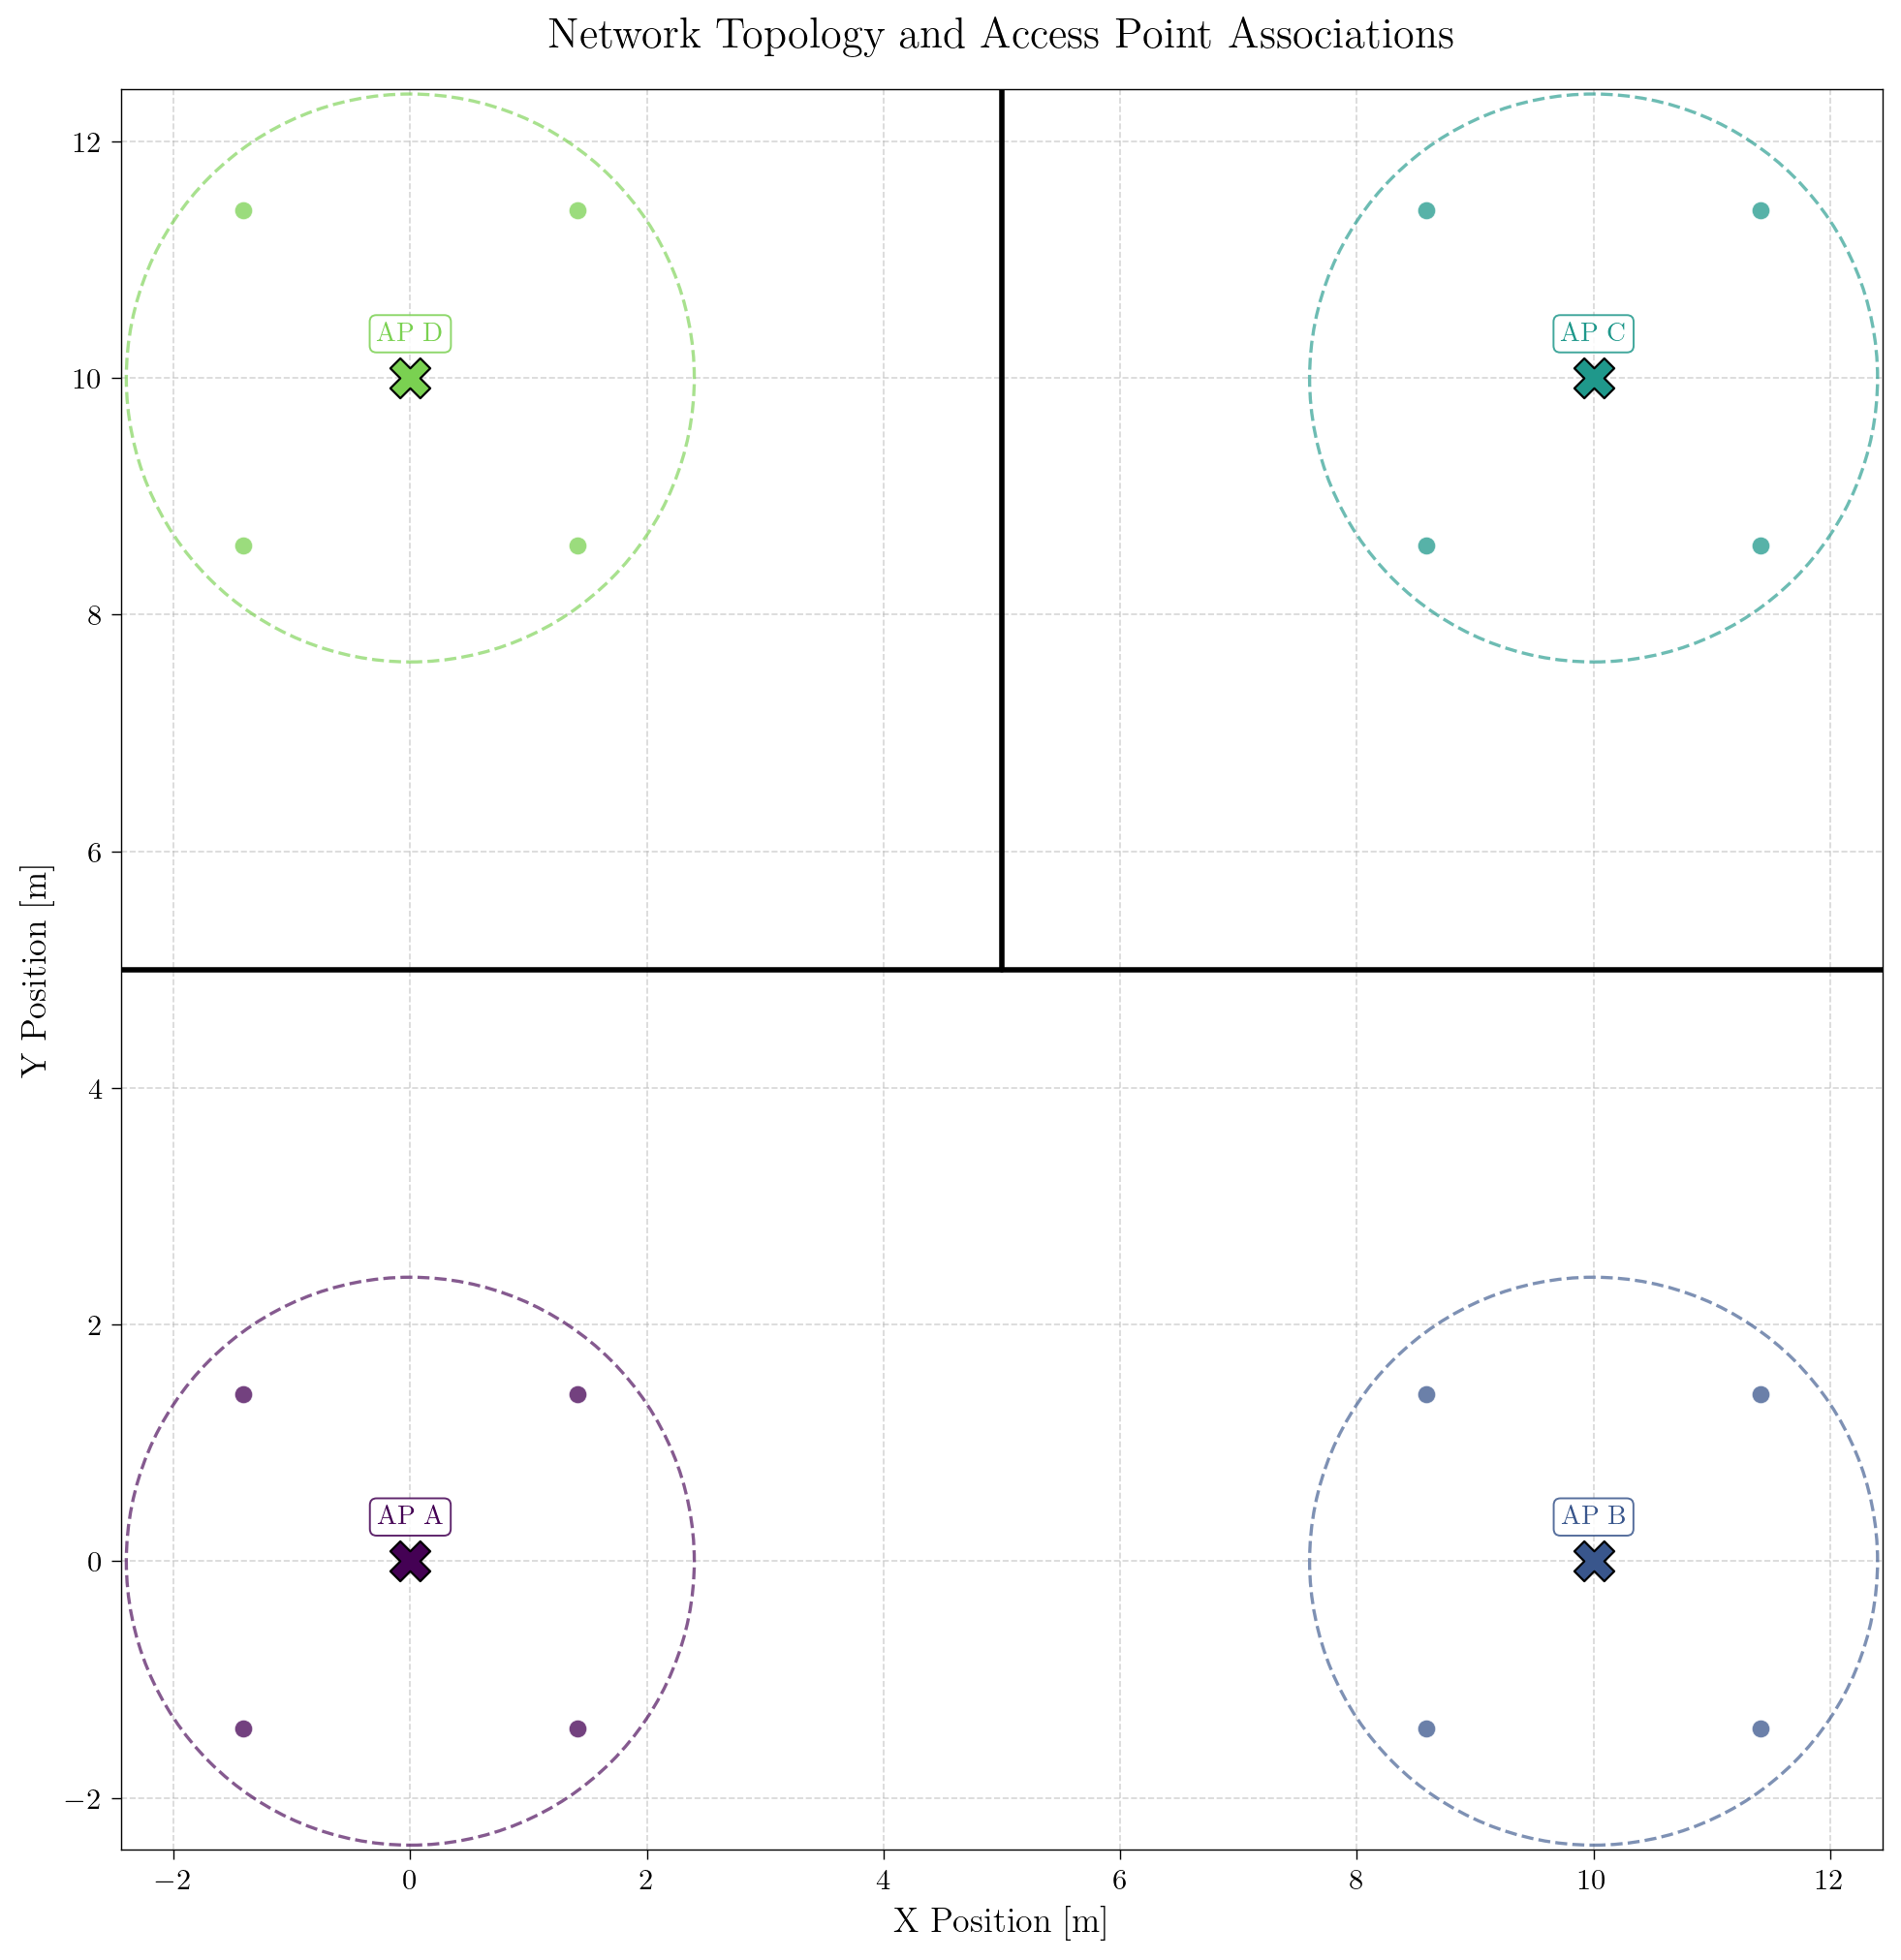

In [3]:
print(scenario.__dict__)
scenario.plot_rs()

In [4]:
total_steps = 5000
n_reps = 2
agent_name = "nr_ucb"
n_tx_power_levels = 4

agent_factory = MapcDQNAgentFactory(
    associations=scenario.associations,
    agent_params_lvl1=None, 
    agent_params_lvl2=None, 
    agent_params_lvl3=None, 
    agent_params_lvl4=None, 
    n_tx_power_levels=n_tx_power_levels, 
    n_links=3, 
    seed=42
)

agent = agent_factory.create_hierarchical_DQN_cmapc_agent()

key = jax.random.PRNGKey(seed=42)

def run_agent(
    run_number: int,
    key: jax.Array,
    n_steps: int = 5_000,
) -> jax.Array:
    """Run a single agent for the specified number of steps."""

    agent = agent_factory.create_hierarchical_DQN_cmapc_agent()
    throughputs = [0.0]

    progress_bar = tqdm(
        range(n_steps - 1),
        desc=f"Run {run_number}",
    )

    for _ in progress_bar:
        key, run_key = jax.random.split(key)

        link_ap_sta = agent.sample(
            reward=throughputs[-1]
        )

        data_rate, reward = scenario(
            run_key,
            link_ap_sta,
        )

        throughputs.append(data_rate)

    return jnp.asarray(throughputs)


def compute_multiple_runs(
    n_runs: int,
    key: jax.Array,
    n_steps: int,
) -> jax.Array:
    """Run multiple independent agent experiments."""

    run_numbers = range(n_runs)
    run_keys = jax.random.split(key, n_runs)

    results = [
        run_agent(
            run_number=run_number,
            key=run_key,
            n_steps=n_steps,
        )
        for run_number, run_key in zip(run_numbers, run_keys)
    ]

    return jnp.stack(results)


throughputs = compute_multiple_runs(
    n_runs=n_reps,
    key=key,
    n_steps=total_steps,
)   

Run 1: 100%|██████████| 4999/4999 [02:46<00:00, 30.03it/s]


In [5]:
import matplotlib.pyplot as plt
import numpy as np 

In [6]:

# ============================================================
# 1. Aggregate Results Across Runs
# ============================================================

throughput = jnp.mean(throughputs, axis=0)
throughput_np = np.asarray(throughput)


# ============================================================
# 2. Smooth Throughput
# ============================================================

window_size = 100

moving_average_kernel = (
    jnp.ones(window_size) / window_size
)

throughput_smoothed = jnp.convolve(
    throughput,
    moving_average_kernel,
)[:total_steps]

throughput_smoothed_np = np.asarray(throughput_smoothed)


# ============================================================
# 3. Build Time Axes
# ============================================================

trials_per_second = 200
time_per_trial = 1.0 / trials_per_second

x_raw = (
    np.arange(len(throughput_np))
    * time_per_trial
)

x_smoothed = (
    np.arange(len(throughput_smoothed_np))
    * time_per_trial
)


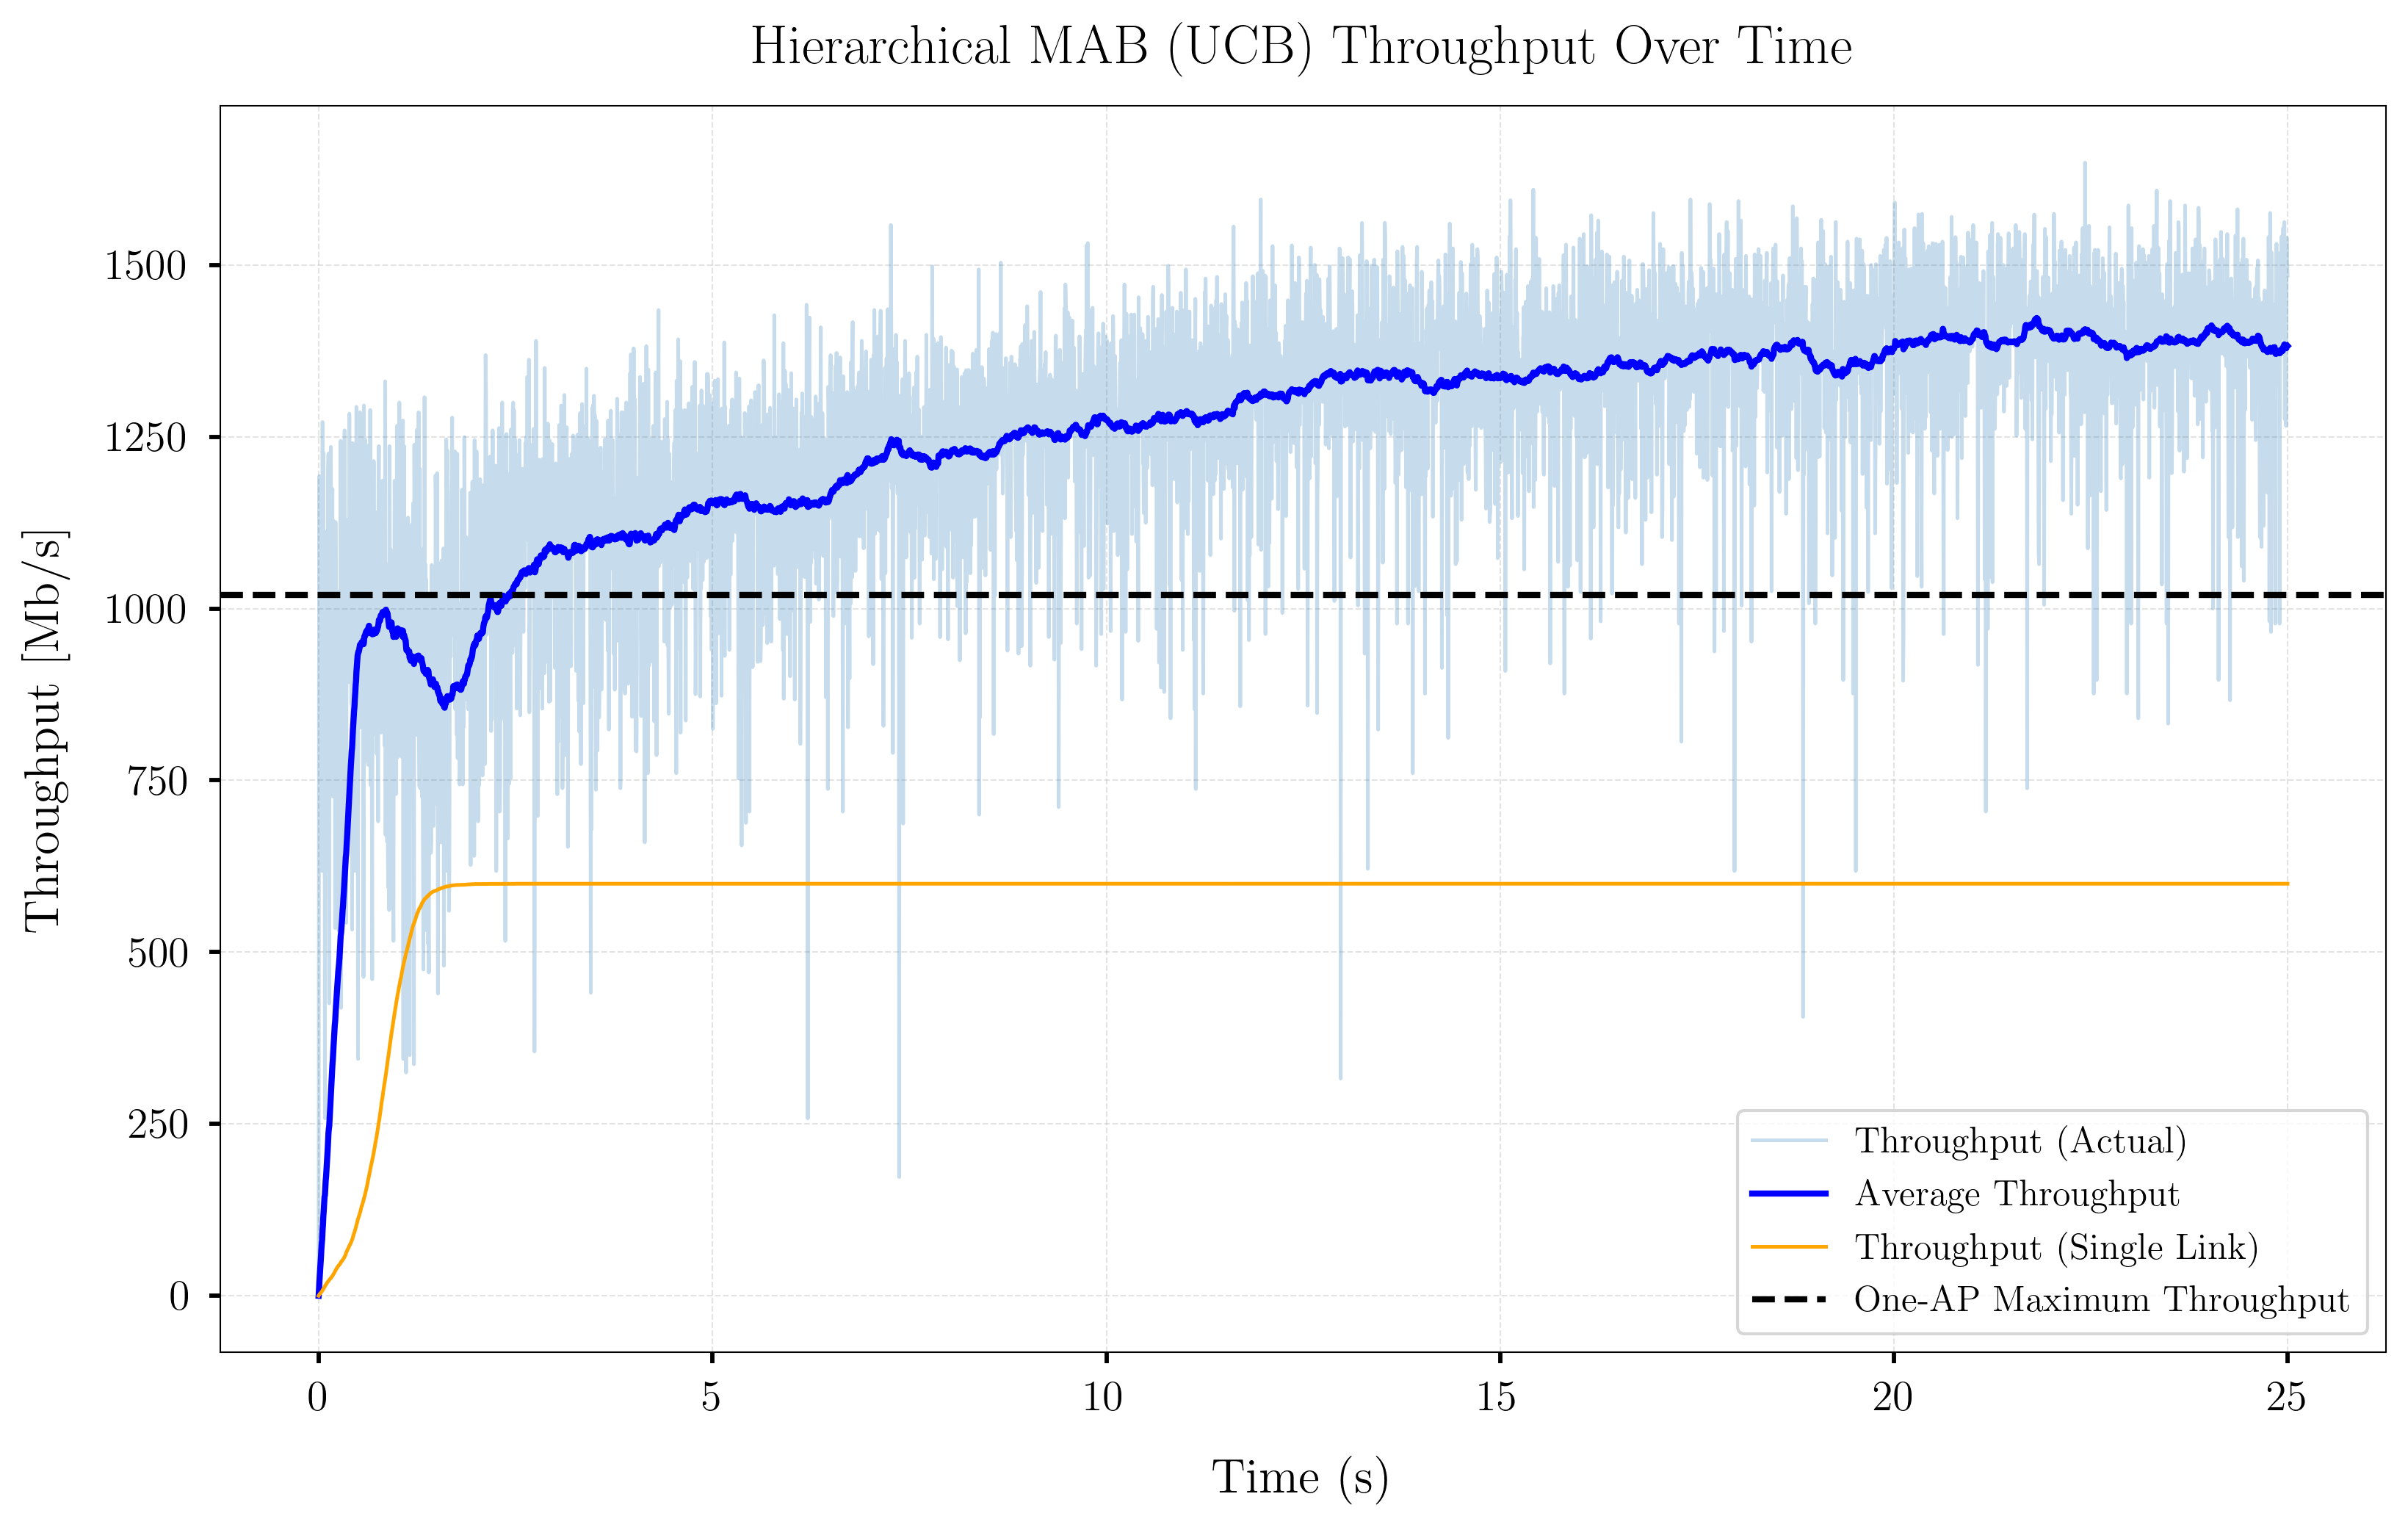

In [7]:


# ============================================================
# 4. Load Single-Link Baseline
# ============================================================

single_link_path = (
    f"C:/Users/studi/Documents/Electronics/"
    f"wireless_networks/wifi-9/"
    f"mab_single_Link/agent_simulations/"
    f"arrays/ucb/d_{d_ap}/"
    f"smoothed_throughput.npy"
)

throughput_single_link = np.asarray(
    jnp.load(single_link_path)
)


# ============================================================
# 5. Plot Throughput
# ============================================================

plt.figure(
    figsize=(11, 7),
    dpi=300,
)

# Raw throughput
plt.plot(
    x_raw,
    throughput_np,
    linewidth=1.2,
    alpha=0.25,
    color="tab:blue",
    label="Throughput (Actual)",
)

# Smoothed hierarchical throughput
plt.plot(
    x_smoothed,
    throughput_smoothed_np,
    linewidth=2,
    color="blue",
    label="Average Throughput",
)

# Single-link baseline
plt.plot(
    x_raw,
    throughput_single_link,
    linewidth=1.2,
    color="orange",
    label="Throughput (Single Link)",
)


# ============================================================
# 6. Configure Plot
# ============================================================

plt.title(
    "Hierarchical MAB (UCB) Throughput Over Time",
    fontsize=18,
    fontweight="bold",
    pad=14,
)

ax = plt.gca()

ax.axhline(
    y=1020,
    linestyle="--",
    linewidth=2,
    color="black",
    label="One-AP Maximum Throughput",
)

ax.set_xlabel(
    "Time (s)",
    fontsize=16,
    fontweight="bold",
    labelpad=12,
)

ax.set_ylabel(
    "Throughput [Mb/s]",
    fontsize=16,
    fontweight="bold",
    labelpad=12,
)

ax.tick_params(
    axis="both",
    labelsize=14,
    width=1.4,
    colors="black",
    pad=6,
)

for tick in (
    ax.get_xticklabels()
    + ax.get_yticklabels()
):
    tick.set_fontweight("bold")
    tick.set_color("black")

ax.grid(
    True,
    linestyle="--",
    alpha=0.35,
)

ax.legend(
    prop={
        "size": 12,
        "weight": "semibold",
    }
)

plt.tight_layout()
plt.show()




